In [1]:
import pandas as pd

appointments = pd.read_csv("../data/raw/appointments.csv", dtype=str)
patients = pd.read_csv("../data/raw/patients.csv", dtype=str)
facilities = pd.read_csv("../data/raw/facilities.csv")

In [2]:
appointments.shape, patients.shape, facilities.shape

((38283, 10), (9070, 8), (16, 5))

## Feature availability rule

A feature can only be used if it would have been known at the moment the appointment was booked.

The modelling features will therefore be limited to information available at booking time, including lead_days, distance_km, reminder_sent, prior_no_shows, service, facility, day of week, and month of year.

Information recorded on or after the appointment date will not be used as a feature.

In [3]:
patients_model = patients.drop_duplicates(
    subset="patient_id",
    keep="first",
).copy()

patients_model.shape

(9000, 8)

### Merge 1: Appointments → Patients

Expected cardinality: many-to-one.

An appointment belongs to one patient, but a patient can have many appointments. Therefore, multiple appointment rows may match the same patient row.

In [4]:
model = appointments.merge(
    patients_model,
    on="patient_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_patient"),
)

In [5]:
model.shape

(38283, 17)

In [6]:
patients_model.shape

(9000, 8)

### Merge 2: Modelling Table → Facilities

Expected cardinality: many-to-one.

Many appointments can belong to the same facility, but each facility_id identifies one facility in the facilities table. Therefore, each appointment should match at most one facility.

In [7]:
model = model.merge(
    facilities,
    on="facility_id",
    how="left",
    validate="many_to_one",
)

In [8]:
model = model.drop(columns="facility_id_patient")

In [9]:
model.columns.tolist()

['appointment_id',
 'patient_id',
 'facility_id',
 'service',
 'booked_ts',
 'scheduled_ts',
 'lead_days',
 'reminder_sent',
 'prior_no_shows',
 'attended',
 'sex',
 'age_band',
 'registered_on',
 'distance_km',
 'has_phone',
 'transport_mode',
 'facility_name',
 'town',
 'facility_type',
 'catchment_population']

In [10]:
model.shape

(38283, 20)

In [11]:
model[["booked_ts", "scheduled_ts"]].head()

,booked_ts,scheduled_ts
0,2025-04-08 06:15:00,15/04/2025 08:15
1,2025-10-19 10:30:00,26/10/2025 15:30
2,2025-03-27 08:00:00,2025-05-11 09:00:00
3,2026-04-23 10:30:00,2026-04-25 12:30:00
4,2025-10-10 06:45:00,2025-10-31 07:45:00


In [12]:
model["booked_ts"] = pd.to_datetime(
    model["booked_ts"],
    errors="coerce",
)

model["scheduled_ts"] = pd.to_datetime(
    model["scheduled_ts"],
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

In [13]:
model[["booked_ts", "scheduled_ts"]].isna().sum()


booked_ts       8270
scheduled_ts    3000
dtype: int64

In [14]:
model["day_of_week"] = model["scheduled_ts"].dt.dayofweek
model["month_of_year"] = model["scheduled_ts"].dt.month

In [15]:
model[["scheduled_ts", "day_of_week", "month_of_year"]].isna().sum()


scheduled_ts     3000
day_of_week      3000
month_of_year    3000
dtype: int64

In [16]:
model["scheduled_ts"].head(20)

0    2025-04-15 08:15:00
1    2025-10-26 15:30:00
2    2025-11-05 09:00:00
3    2026-04-25 12:30:00
4    2025-10-31 07:45:00
5    2025-09-10 14:15:00
6    2026-11-07 10:45:00
7    2025-06-12 09:15:00
8    2026-02-17 07:00:00
9    2025-01-26 14:30:00
10   2025-06-21 08:00:00
11   2025-08-26 10:15:00
12   2025-11-08 12:45:00
13                   NaT
14                   NaT
15   2025-11-29 10:15:00
16   2025-06-17 13:45:00
17   2026-09-05 09:45:00
18   2025-09-09 08:15:00
19   2025-08-14 07:15:00
Name: scheduled_ts, dtype: datetime64[us]

In [17]:
appointments["scheduled_ts"].head(20).tolist()


['15/04/2025 08:15',
 '26/10/2025 15:30',
 '2025-05-11 09:00:00',
 '2026-04-25 12:30:00',
 '2025-10-31 07:45:00',
 '10/09/2025 14:15',
 '2026-07-11 10:45:00',
 '2025-12-06 09:15:00',
 '17/02/2026 07:00',
 '2025-01-26 14:30:00',
 '2025-06-21 08:00:00',
 '2025-08-26 10:15:00',
 '2025-08-11 12:45:00',
 '1768562100',
 '1759230000',
 '2025-11-29 10:15:00',
 '2025-06-17 13:45:00',
 '2026-05-09 09:45:00',
 '2025-09-09 08:15:00',
 '2025-08-14 07:15:00']

In [18]:
model = appointments.merge(
    patients_model,
    on="patient_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_patient"),
)

model = model.drop(columns="facility_id_patient")

model = model.merge(
    facilities,
    on="facility_id",
    how="left",
    validate="many_to_one",
)

In [19]:
def parse_mixed_datetime(series):
    values = series.astype("string").str.strip()

    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    numeric = values.str.fullmatch(r"\d+").fillna(False)

    result.loc[numeric] = pd.to_datetime(
        pd.to_numeric(values[numeric]),
        unit="s",
        errors="coerce",
    )

    result.loc[~numeric] = pd.to_datetime(
        values[~numeric],
        format="mixed",
        dayfirst=True,
        errors="coerce",
    )

    return result

In [20]:
model["booked_ts"] = parse_mixed_datetime(model["booked_ts"])
model["scheduled_ts"] = parse_mixed_datetime(model["scheduled_ts"])

In [21]:
model[["booked_ts", "scheduled_ts"]].isna().sum()

booked_ts       0
scheduled_ts    0
dtype: int64

In [22]:
model["day_of_week"] = model["scheduled_ts"].dt.dayofweek
model["month_of_year"] = model["scheduled_ts"].dt.month

In [23]:
model[["scheduled_ts", "day_of_week", "month_of_year"]].head()

,scheduled_ts,day_of_week,month_of_year
0,2025-04-15 08:15:00,1,4
1,2025-10-26 15:30:00,6,10
2,2025-11-05 09:00:00,2,11
3,2026-04-25 12:30:00,5,4
4,2025-10-31 07:45:00,4,10


In [24]:
feature_columns = [
    "lead_days",
    "distance_km",
    "reminder_sent",
    "prior_no_shows",
    "service",
    "facility_id",
    "day_of_week",
    "month_of_year",
]

target_column = "attended"

In [25]:
X = model[feature_columns].copy()
y = model[target_column].copy()

In [26]:
X.columns.tolist(), y.name

(['lead_days',
  'distance_km',
  'reminder_sent',
  'prior_no_shows',
  'service',
  'facility_id',
  'day_of_week',
  'month_of_year'],
 'attended')

## Feature availability at booking time

The model only uses information that would have been known when the appointment was booked.

Allowed features:
- lead_days
- distance_km
- reminder_sent
- prior_no_shows
- service
- facility_id
- day_of_week
- month_of_year

The target is attended and is not used as a feature.

Information recorded on or after the appointment date is excluded from the feature table.

In [27]:
model.columns.tolist()

['appointment_id',
 'patient_id',
 'facility_id',
 'service',
 'booked_ts',
 'scheduled_ts',
 'lead_days',
 'reminder_sent',
 'prior_no_shows',
 'attended',
 'sex',
 'age_band',
 'registered_on',
 'distance_km',
 'has_phone',
 'transport_mode',
 'facility_name',
 'town',
 'facility_type',
 'catchment_population',
 'day_of_week',
 'month_of_year']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30626, 8), (7657, 8), (30626,), (7657,))

In [30]:
model.info(memory_usage="deep")


<class 'pandas.DataFrame'>
RangeIndex: 38283 entries, 0 to 38282
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   appointment_id        38283 non-null  str           
 1   patient_id            38283 non-null  str           
 2   facility_id           38283 non-null  str           
 3   service               38283 non-null  str           
 4   booked_ts             38283 non-null  datetime64[ns]
 5   scheduled_ts          38283 non-null  datetime64[ns]
 6   lead_days             38283 non-null  str           
 7   reminder_sent         38283 non-null  str           
 8   prior_no_shows        38283 non-null  str           
 9   attended              38283 non-null  str           
 10  sex                   37883 non-null  str           
 11  age_band              32922 non-null  str           
 12  registered_on         37883 non-null  str           
 13  distance_km           25281

In [31]:
memory_before = model.memory_usage(deep=True).sum()

memory_before / 1024**2

np.float64(35.07471942901611)

In [32]:
model["lead_days"] = pd.to_numeric(
    model["lead_days"],
    errors="coerce",
).astype("Int16")

model["distance_km"] = (
    model["distance_km"]
    .astype("string")
    .str.replace(" km", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
    .astype("Float32")
)

model["prior_no_shows"] = pd.to_numeric(
    model["prior_no_shows"],
    errors="coerce",
).astype("Int16")

model["catchment_population"] = model[
    "catchment_population"
].astype("int32")

for column in [
    "facility_id",
    "service",
    "sex",
    "age_band",
    "has_phone",
    "transport_mode",
    "facility_name",
    "town",
    "facility_type",
]:
    model[column] = model[column].astype("category")

In [33]:
model.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 38283 entries, 0 to 38282
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   appointment_id        38283 non-null  str           
 1   patient_id            38283 non-null  str           
 2   facility_id           38283 non-null  category      
 3   service               38283 non-null  category      
 4   booked_ts             38283 non-null  datetime64[ns]
 5   scheduled_ts          38283 non-null  datetime64[ns]
 6   lead_days             36781 non-null  Int16         
 7   reminder_sent         38283 non-null  str           
 8   prior_no_shows        38283 non-null  Int16         
 9   attended              38283 non-null  str           
 10  sex                   37883 non-null  category      
 11  age_band              32922 non-null  category      
 12  registered_on         37883 non-null  str           
 13  distance_km           25281

In [34]:
memory_after = model.memory_usage(deep=True).sum()

memory_reduction = (
    (memory_before - memory_after)
    / memory_before
    * 100
)

memory_before / 1024**2, memory_after / 1024**2, memory_reduction

(np.float64(35.07471942901611),
 np.float64(11.894707679748535),
 np.float64(66.0875186647724))

In [35]:
model[["reminder_sent", "attended", "lead_days"]].head()

,reminder_sent,attended,lead_days
0,0,Yes,7
1,True,Yes,7
2,0,Yes,45
3,1,yes,2
4,FALSE,yes,21


In [36]:
model[["reminder_sent", "attended"]].value_counts(dropna=False)

reminder_sent  attended
TRUE           YES         1802
1              yes         1488
               Yes         1479
yes            yes         1479
               Yes         1464
True           yes         1460
               Yes         1459
               YES         1455
TRUE           yes         1434
1              YES         1426
yes            YES         1405
TRUE           Yes         1402
FALSE          YES         1224
no             Yes         1185
False          Yes         1177
               yes         1168
               YES         1165
0              Yes         1146
FALSE          Yes         1142
no             yes         1135
0              YES         1132
no             YES         1103
0              yes         1103
FALSE          yes         1067
TRUE           NO           322
0              No           313
False          NO           309
no             NO           305
FALSE          NO           300
True           NO           299
               N

In [37]:
def clean_binary(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .map({
            "1": 1,
            "true": 1,
            "yes": 1,
            "0": 0,
            "false": 0,
            "no": 0,
        })
        .astype("Int8")
    )


model["reminder_sent"] = clean_binary(model["reminder_sent"])
model["attended"] = clean_binary(model["attended"])

In [38]:
model[["reminder_sent", "attended"]].value_counts(dropna=False)

reminder_sent  attended
1              1           17753
0              1           13747
               0            3397
1              0            3386
Name: count, dtype: int64

In [39]:
X = model[feature_columns].copy()
y = model[target_column].copy()

In [40]:
X.dtypes

lead_days            Int16
distance_km        Float32
reminder_sent         Int8
prior_no_shows       Int16
service           category
facility_id       category
day_of_week          int32
month_of_year        int32
dtype: object

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [42]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30626, 8), (7657, 8), (30626,), (7657,))

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "lead_days",
    "distance_km",
    "prior_no_shows",
    "day_of_week",
    "month_of_year",
]

categorical_features = [
    "service",
    "facility_id",
]

In [44]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [46]:
X_train_processed.shape, X_test_processed.shape

((30626, 30), (7657, 30))

## Memory reduction

The modelling table was reduced from 35.07 MB to 11.89 MB by optimizing numeric dtypes and converting repeated categorical string columns to the category dtype.

This represents a 66.09% reduction in memory usage, exceeding the required 50% reduction.

In [47]:
y_train.value_counts()

attended
1    25200
0     5426
Name: count, dtype: Int64

In [48]:
y_train.value_counts(normalize=True)

attended
1    0.82283
0    0.17717
Name: proportion, dtype: Float64

In [49]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_processed, y_train)

baseline_predictions = baseline.predict(X_test_processed)

In [50]:
from sklearn.metrics import accuracy_score, recall_score

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions,
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
)

baseline_accuracy, baseline_recall

(0.8227765443385138, 1.0)

In [51]:
y_train_no_show = 1 - y_train
y_test_no_show = 1 - y_test

In [105]:
y_train

33847    0
19686    0
1184     1
3451     1
33850    1
        ..
20283    1
13065    1
36333    1
31598    1
23296    1
Name: attended, Length: 30626, dtype: Int8

In [106]:
y_test

17033    1
31161    1
30745    1
28308    1
26814    1
        ..
30111    0
23697    0
21271    0
20234    1
32674    1
Name: attended, Length: 7657, dtype: Int8

In [107]:
y_train_no_show = (y_train == 0).astype("int8")
y_test_no_show = (y_test == 0).astype("int8")

y_train_no_show.value_counts(), y_test_no_show.value_counts()

(attended
 0    25200
 1     5426
 Name: count, dtype: int64,
 attended
 0    6300
 1    1357
 Name: count, dtype: int64)

In [111]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "service",
    "facility_id",
]

numeric_features = [
    "lead_days",
    "distance_km",
    "reminder_sent",
    "prior_no_shows",
    "day_of_week",
    "month_of_year",
]

numeric_preprocessor = SimpleImputer(
    strategy="median"
)

categorical_preprocessor = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
        (
            "numeric",
            numeric_preprocessor,
            numeric_features,
        ),
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

naive_bayes_model = GaussianNB()

logistic_model.fit(
    X_train_encoded,
    y_train_no_show
)

decision_tree_model.fit(
    X_train_encoded,
    y_train_no_show
)

knn_model.fit(
    X_train_encoded,
    y_train_no_show
)

naive_bayes_model.fit(
    X_train_encoded,
    y_train_no_show
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[25200., 5426.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.82,0.18]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int8](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.664e-07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,31
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 31)","[[0.11,0.11,0.11,...,0.34,2.99,6.26], [0.12,0.12,0.11,...,0.81,3.03,6.42]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 31)","[[ 0.1 , 0.1 , 0.1 ,..., 0.49, 3.98,11.93], [ 0.1 , 0.1 , 0.1 ,..., 1.31, 3.89,11.41]]"


In [114]:
logistic_predictions = logistic_model.predict(X_test_encoded)
logistic_probabilities = logistic_model.predict_proba(X_test_encoded)[:, 1]

decision_tree_predictions = decision_tree_model.predict(X_test_encoded)
decision_tree_probabilities = decision_tree_model.predict_proba(X_test_encoded)[:, 1]

knn_predictions = knn_model.predict(X_test_encoded)
knn_probabilities = knn_model.predict_proba(X_test_encoded)[:, 1]

naive_bayes_predictions = naive_bayes_model.predict(X_test_encoded)
naive_bayes_probabilities = naive_bayes_model.predict_proba(X_test_encoded)[:, 1]

In [115]:
logistic_predictions.shape, logistic_probabilities.shape

((7657,), (7657,))

In [116]:
import numpy as np
import pandas as pd

majority_prediction = np.zeros(
    len(y_test_no_show),
    dtype=int
)

majority_probability = np.zeros(
    len(y_test_no_show)
)

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

results = []

results.append({
    "model": "Majority Baseline",
    "accuracy": accuracy_score(
        y_test_no_show,
        majority_prediction,
    ),
    "precision": precision_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "pr_auc": np.nan,
})

models = {
    "Logistic Regression": (
        logistic_predictions,
        logistic_probabilities,
    ),
    "Decision Tree": (
        decision_tree_predictions,
        decision_tree_probabilities,
    ),
    "K-Nearest Neighbours": (
        knn_predictions,
        knn_probabilities,
    ),
    "Naive Bayes": (
        naive_bayes_predictions,
        naive_bayes_probabilities,
    ),
}

for name, (predictions, probabilities) in models.items():

    results.append({
        "model": name,
        "accuracy": accuracy_score(
            y_test_no_show,
            predictions,
        ),
        "precision": precision_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "pr_auc": average_precision_score(
            y_test_no_show,
            probabilities,
        ),
    })

comparison = pd.DataFrame(results)

comparison

,model,accuracy,precision,recall,f1,pr_auc
0,Majority Baseline,0.822777,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,0.826172,0.573034,0.075166,0.132899,0.342678
2,Decision Tree,0.719734,0.229609,0.246868,0.237926,0.190308
3,K-Nearest Neighbours,0.808933,0.371981,0.113486,0.173913,0.230423
4,Naive Bayes,0.812720,0.439938,0.207811,0.282282,0.321322


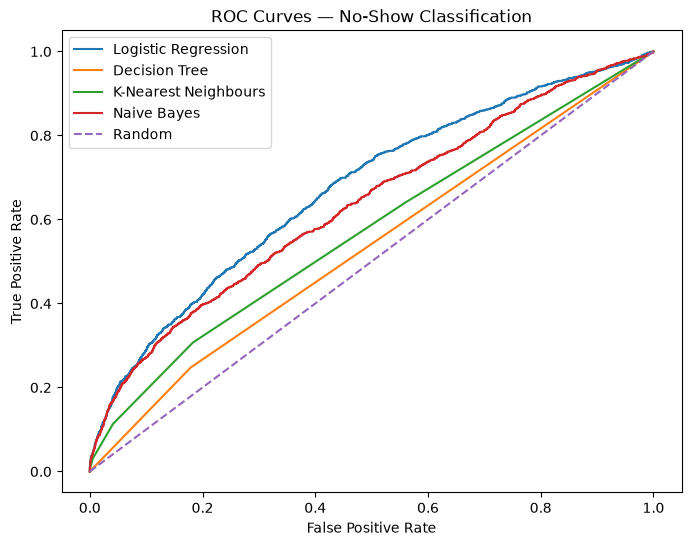

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": decision_tree_probabilities,
    "K-Nearest Neighbours": knn_probabilities,
    "Naive Bayes": naive_bayes_probabilities,
}

plt.figure(figsize=(8, 6))

for name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_test_no_show,
        probabilities,
    )

    plt.plot(
        fpr,
        tpr,
        label=name,
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — No-Show Classification")
plt.legend()
plt.show()

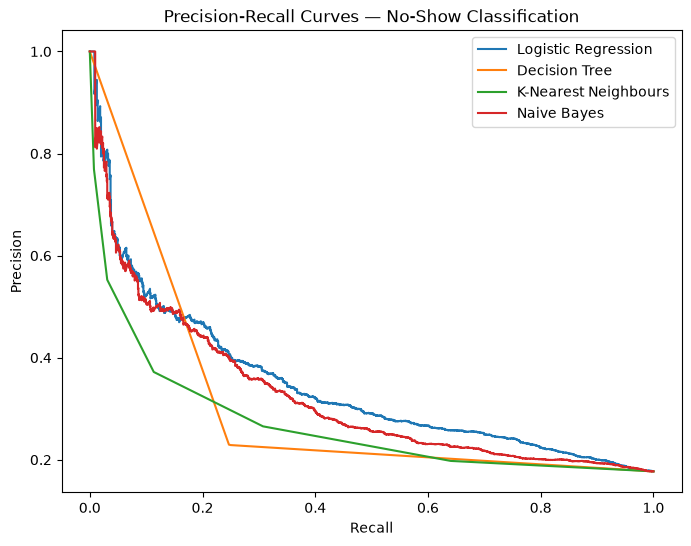

In [120]:
plt.figure(figsize=(8, 6))

for name, probabilities in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test_no_show,
        probabilities,
    )

    plt.plot(
        recall,
        precision,
        label=name,
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — No-Show Classification")
plt.legend()
plt.show()

In [121]:
import numpy as np
from sklearn.metrics import confusion_matrix

false_positive_cost = 500
false_negative_cost = 5000

thresholds = np.arange(
    0.01,
    1.00,
    0.01,
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_no_show,
        predictions,
        labels=[0, 1],
    ).ravel()

    total_cost = (
        fp * false_positive_cost
        + fn * false_negative_cost
    )

    threshold_results.append({
        "threshold": threshold,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost_xaf": total_cost,
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,threshold,false_positives,false_negatives,true_positives,true_negatives,total_cost_xaf
0,0.01,6300,0,1357,0,3150000
1,0.02,6300,0,1357,0,3150000
2,0.03,6300,0,1357,0,3150000
3,0.04,6300,0,1357,0,3150000
4,0.05,6300,0,1357,0,3150000
...,...,...,...,...,...,...
94,0.95,0,1357,0,6300,6785000
95,0.96,0,1357,0,6300,6785000
96,0.97,0,1357,0,6300,6785000
97,0.98,0,1357,0,6300,6785000


In [122]:
best_threshold = threshold_results.loc[
    threshold_results["total_cost_xaf"].idxmin()
]

best_threshold

threshold                0.11
false_positives       4706.00
false_negatives        150.00
true_positives        1207.00
true_negatives        1594.00
total_cost_xaf     3103000.00
Name: 10, dtype: float64

In [123]:
threshold_distance = abs(
    best_threshold["threshold"] - 0.50
)

threshold_distance

np.float64(0.39)

In [124]:
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(
    y_test_no_show,
    logistic_probabilities,
)

brier_before

0.1354100481652931

In [125]:
from sklearn.linear_model import LogisticRegression

platt_model = LogisticRegression(
    random_state=42
)

platt_model.fit(
    logistic_model.predict_proba(X_train_encoded)[:, 1].reshape(-1, 1),
    y_train_no_show,
)

calibrated_probabilities = platt_model.predict_proba(
    logistic_probabilities.reshape(-1, 1)
)[:, 1]

In [126]:
brier_after = brier_score_loss(
    y_test_no_show,
    calibrated_probabilities,
)

brier_change = brier_after - brier_before

brier_after, brier_change

(0.13586875766946757, 0.00045870950417448153)

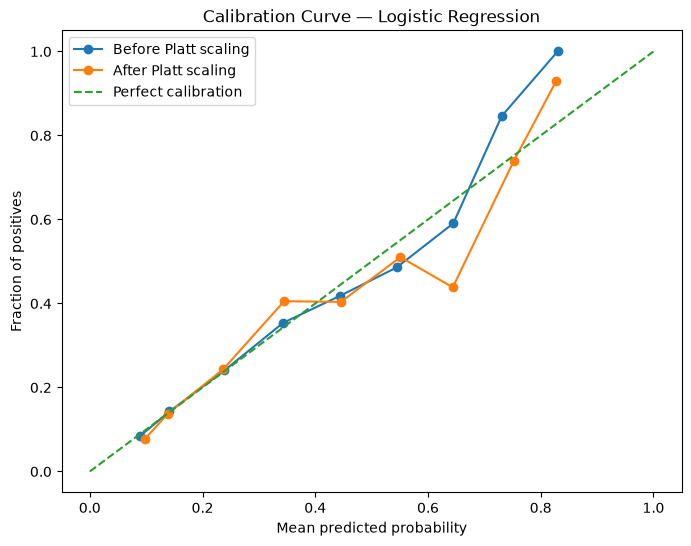

In [128]:
from sklearn.calibration import calibration_curve

prob_true_before, prob_pred_before = calibration_curve(
    y_test_no_show,
    logistic_probabilities,
    n_bins=10,
    strategy="uniform",
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test_no_show,
    calibrated_probabilities,
    n_bins=10,
    strategy="uniform",
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before Platt scaling",
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="After Platt scaling",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Logistic Regression")
plt.legend()
plt.show()

In [130]:
test_dates = appointments.loc[
    X_test.index,
    "scheduled_ts"
]

test_dates = pd.to_datetime(
    test_dates,
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

weeks = (
    test_dates.max() - test_dates.min()
).days / 7

reminder_calls = (
    best_threshold["false_positives"]
    + best_threshold["true_positives"]
)

reminder_calls_per_week = (
    reminder_calls / weeks
)

weeks, reminder_calls, reminder_calls_per_week

(100.71428571428571, np.float64(5913.0), np.float64(58.71063829787234))